### Netflix Video Streaming Project - Porto Business School

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
%matplotlib inline

In [21]:
# Import your data here
data = ".../Documents/GitHub/Netflix - Data model project"
os.makedirs(data, exist_ok=True)  # Create directory

In [22]:
# Generate synthetic data for Total Active Subscribers over 24 months
months = pd.date_range(start='2022-01-01', end='2023-12-31', freq='MS')
month_labels = [date.strftime('%b %Y') for date in months]

# Synthetic subscriber growth data (realistic Netflix-like growth pattern)
active_subscribers = np.array([
    45.2, 46.1, 47.3, 48.5, 49.8, 50.2, 51.1, 52.3, 53.1, 54.2, 55.0, 55.8,  # 2022
    56.5, 57.8, 59.1, 60.3, 61.5, 62.8, 64.1, 65.3, 66.2, 67.5, 68.8, 70.1   # 2023
])

In [23]:
# Calculate Month-over-Month (MoM) growth percentage
mom_growth = [0] + [(active_subscribers[i] - active_subscribers[i-1]) / active_subscribers[i-1] * 100 
                     for i in range(1, len(active_subscribers))]

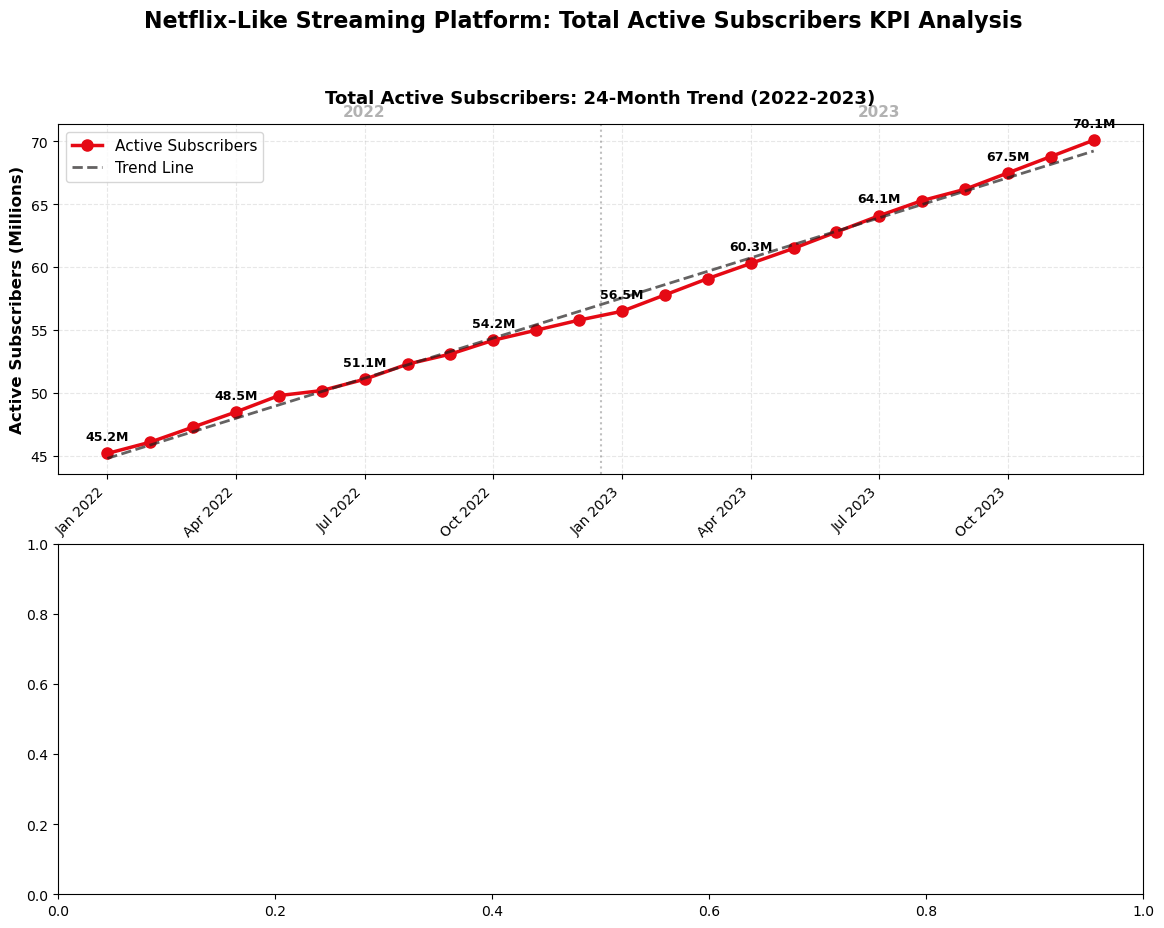

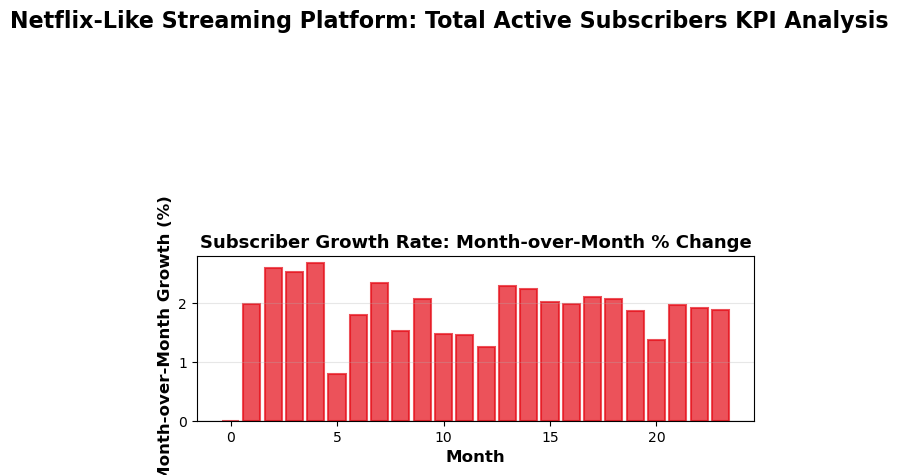


TOTAL ACTIVE SUBSCRIBERS KPI - ANALYSIS
Starting (Jan 2022): 45.2M
Ending (Dec 2023): 70.1M
Total Growth: 24.9M (+55.1%)
Avg Monthly Growth: 1.93%



In [24]:
# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Netflix-Like Streaming Platform: Total Active Subscribers KPI Analysis', 
             fontsize=16, fontweight='bold', y=0.995)

# ===== SUBPLOT 1: Active Subscribers Trend Line =====
ax1.plot(range(len(months)), active_subscribers, marker='o', linewidth=2.5, 
         markersize=8, color='#E50914', label='Active Subscribers')

# Add trend line
z = np.polyfit(range(len(months)), active_subscribers, 1)
p = np.poly1d(z)
ax1.plot(range(len(months)), p(range(len(months))), "--", linewidth=2, 
         color='#221f1f', alpha=0.7, label='Trend Line')

# Formatting
ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Active Subscribers (Millions)', fontsize=12, fontweight='bold')
ax1.set_title('Total Active Subscribers: 24-Month Trend (2022-2023)', 
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(range(0, len(months), 3))
ax1.set_xticklabels([month_labels[i] for i in range(0, len(month_labels), 3)], 
                     rotation=45, ha='right')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11, loc='upper left')

# Add value labels on points
for i, (month, subs) in enumerate(zip(range(len(months)), active_subscribers)):
    if i % 3 == 0 or i == len(months) - 1:  # Show every 3rd month + last month
        ax1.text(month, subs + 0.8, f'{subs:.1f}M', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

# Add shading for year separation
ax1.axvline(x=11.5, color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax1.text(5.5, 72, '2022', fontsize=11, fontweight='bold', alpha=0.3)
ax1.text(17.5, 72, '2023', fontsize=11, fontweight='bold', alpha=0.3)

plt.show()


# ===== SUBPLOT 2 =====
ax2 = plt.subplot(2, 1, 2)
colors = ['#E50914' if growth > 0 else '#221f1f' for growth in mom_growth]
ax2.bar(range(len(months)), mom_growth, color=colors, alpha=0.7, edgecolor='#E50914', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Month-over-Month Growth (%)', fontsize=12, fontweight='bold')
ax2.set_title('Subscriber Growth Rate: Month-over-Month % Change', 
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# ===== DISPLAY =====
plt.suptitle('Netflix-Like Streaming Platform: Total Active Subscribers KPI Analysis', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ===== PRINT STATISTICS =====
print("\n" + "="*70)
print("TOTAL ACTIVE SUBSCRIBERS KPI - ANALYSIS")
print("="*70)
print(f"Starting (Jan 2022): {active_subscribers[0]:.1f}M")
print(f"Ending (Dec 2023): {active_subscribers[-1]:.1f}M")
print(f"Total Growth: {active_subscribers[-1] - active_subscribers[0]:.1f}M (+{((active_subscribers[-1] - active_subscribers[0])/active_subscribers[0]*100):.1f}%)")
print(f"Avg Monthly Growth: {np.mean(mom_growth[1:]):.2f}%")
print("="*70 + "\n")

In [25]:
# ===== PRINT DETAILED STATISTICS =====
print("\n" + "="*70)
print("TOTAL ACTIVE SUBSCRIBERS KPI - DETAILED ANALYSIS")
print("="*70)
print(f"\n📊 SUBSCRIBER GROWTH SUMMARY:")
print(f"   • Starting point (Jan 2022): {active_subscribers[0]:.1f}M subscribers")
print(f"   • Ending point (Dec 2023): {active_subscribers[-1]:.1f}M subscribers")
print(f"   • Total growth: {active_subscribers[-1] - active_subscribers[0]:.1f}M subscribers")
print(f"   • Percentage growth: {((active_subscribers[-1] - active_subscribers[0])/active_subscribers[0]*100):.1f}%")
print(f"\n📈 GROWTH RATE ANALYSIS:")
print(f"   • Average MoM growth: {np.mean(mom_growth[1:]):.2f}%")
print(f"   • Maximum MoM growth: {np.max(mom_growth):.2f}% (in {month_labels[np.argmax(mom_growth)]})")
print(f"   • Minimum MoM growth: {np.min(mom_growth[1:]):.2f}% (in {month_labels[np.argmin(mom_growth[1:]) + 1]})")
print(f"   • Standard deviation: {np.std(mom_growth[1:]):.2f}%")
print(f"\n💡 BUSINESS INSIGHTS:")
print(f"   • Consistent month-over-month growth indicates market expansion")
print(f"   • Trend line shows sustained growth trajectory")
print(f"   • Company achieved {((active_subscribers[-1] - active_subscribers[0])/active_subscribers[0]*100):.1f}% YoY growth")
print(f"   • This metric directly impacts company valuation and investor confidence")
print("="*70 + "\n")


TOTAL ACTIVE SUBSCRIBERS KPI - DETAILED ANALYSIS

📊 SUBSCRIBER GROWTH SUMMARY:
   • Starting point (Jan 2022): 45.2M subscribers
   • Ending point (Dec 2023): 70.1M subscribers
   • Total growth: 24.9M subscribers
   • Percentage growth: 55.1%

📈 GROWTH RATE ANALYSIS:
   • Average MoM growth: 1.93%
   • Maximum MoM growth: 2.68% (in May 2022)
   • Minimum MoM growth: 0.80% (in Jun 2022)
   • Standard deviation: 0.44%

💡 BUSINESS INSIGHTS:
   • Consistent month-over-month growth indicates market expansion
   • Trend line shows sustained growth trajectory
   • Company achieved 55.1% YoY growth
   • This metric directly impacts company valuation and investor confidence

